---
---

# $$Heart \ Disease: \ A \ Weighted \ Gradient \ Boosting \ Approach$$


---
---

## $$Setup$$

### Install dependencies

In [ ]:
%%capture
!pip install itables
!pip install optuna-integration[xgboost]
!pip install catboost
# !pip install scikit-learn==1.3.1 # for target_encoder

### Imports

In [ ]:
import os
from typing import Optional
from dataclasses import dataclass, asdict, field

import time
import torch
import random
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=False,connected=True)

# Sklearn Preprocessing
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, PolynomialFeatures, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# The Models
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor

# Metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score, mean_squared_error

# Hyperparameter search
import optuna

# Set plot style
sns.set_style("darkgrid")

# Silence FutureWarnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Configurations

In [ ]:
import os
import torch
from dataclasses import dataclass, asdict, field
from typing import Optional

@dataclass
class EnvConfig:
    competition: str = "s6e2"
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    smoke_test: bool = True
    report_to_wandb: bool = False
    use_accelerator: bool = True
    mixed_precision: bool = False
    is_kaggle: bool = False # True if running on kaggle else False (colab)

@dataclass
class DataConfig:
    data_path: str = ""
    extra_path: str = ""
    target: str = "heart_disease"
    metric: str = "roc_auc"
    folds: int = 5
    add_extra_data: bool = False if extra_path == "" else True
    add_features: bool = True
    feature_selection: bool = True
    use_te: bool = False # Target Encoding

@dataclass
class ModelConfig:
    task_type: str = "classification"
    model_type: str = "tree-based"
    adversarial_threshold: float = 0.65
    hp_search: bool = False
    optimized_params: bool = False
    search_weights: bool = True
    optuna_trials: int = 30
    params: dict = field(default_factory=lambda: {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "learning_rate": 0.05,
        "max_depth": 6,
        "tree_method": "gpu_hist" if torch.cuda.is_available() else "hist",
    })

@dataclass
# NOTE: Use default_factory for mutable default values to prevent unintended shared state.
class CFG:
    env: EnvConfig = field(default_factory=EnvConfig)
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)

    # Placeholder for the secret key
    wandb_api_key: Optional[str] = field(default=None, repr=False)

    def __post_init__(self):
        """Runs automatically after the class is initialized."""
        # 1. Handle W&B Secrets
        if self.env.report_to_wandb:
          if self.env.is_kaggle:
            try:
                from kaggle_secrets import UserSecretsClient
                os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")
                print("✅ Secrets loaded.")
            except Exception as e:
                print(f"ℹ️ Kaggle secrets not found: {e}")
          else:
            try:
                from google.colab import userdata
                os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
                os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
                os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
                print("✅ Secrets loaded.")
            except Exception as e:
                print(f"ℹ️ Colab secrets not found: {e}")

        # # 2. Handle cuML Acceleration
        # if self.env.use_accelerator:
        #     try:
        #         import cuml.accel
        #         cuml.accel.install()
        #         print("⚡ GPU Acceleration Enabled")
        #     except Exception as e:
        #         print(f"ℹ️ cuML Acceleration unavailable: {e}")

    def to_dict(self):
        """Best for wandb.init(config=...)"""
        return asdict(self)

# Instantiate
config = CFG()
if config.env.is_kaggle:
    config.data.data_path = '/kaggle/input/competitions/playground-series-s6e2'
else:
    import kagglehub
    playground_series_path = kagglehub.competition_download(f'playground-series-{config.env.competition}')
    config.data.data_path = playground_series_path

In [ ]:
# Sets the seed for reproducibility in numpy, random, torch CPU, and CUDA.
np.random.seed(config.env.seed)
random.seed(config.env.seed)
torch.manual_seed(config.env.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config.env.seed)
    torch.cuda.manual_seed_all(config.env.seed) # For multi-GPU setups.
    torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

In [ ]:
# import wandb
# wandb.init(project=config.env.competition, config=config.to_dict())

In [ ]:
#@title Helper functions
from math import e
# ==================== HELPER FUNCTIONS ====================

def iqr_outlier_capping(train, valid=None, test=None, columns=None):
    """
    Applies IQR-based outlier capping to specified columns of one, two, or three DataFrames.

    Parameters:
        train (pd.DataFrame): The training DataFrame used to calculate IQR thresholds.
        valid (pd.DataFrame, optional): The validation DataFrame to cap using train thresholds.
        test (pd.DataFrame, optional): The test DataFrame to cap using train thresholds.
        columns (list, optional): List of column names to apply capping to. If None, applies to all numerical columns.

    Returns:
        tuple: A tuple containing:
            - train_capped (pd.DataFrame): Capped training DataFrame.
            - valid_capped (pd.DataFrame or None): Capped validation DataFrame (if provided).
            - test_capped (pd.DataFrame or None): Capped test DataFrame (if provided).

    Note: Make sure there are no nans
    """
    train_capped = train.copy() # Avoid modifying the original DataFrame
    valid_capped = valid.copy() if valid is not None else None
    test_capped = test.copy() if test is not None else None

    if columns is None:
        columns = train.select_dtypes(include='number').columns.tolist()  # All numerical columns

    # Calculate IQR-based thresholds from the training set
    # w/ .dropna() to handle cols with nans: required by np.percentile
    for col in columns:
        Q1 = np.percentile(train[col].dropna(), 25)
        Q3 = np.percentile(train[col].dropna(), 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Show Values
        # print(f'Columns {col}: \tLower Bound is: {lower_bound:.2f} \tUpper Bound is: {upper_bound:.2f}')

        # Cap outliers in the training set
        train_capped[col] = np.clip(train_capped[col], lower_bound, upper_bound)

        # If validation set is provided, cap using training set thresholds
        if valid is not None:
            valid_capped[col] = np.clip(valid[col], lower_bound, upper_bound)

        # If test set is provided, cap using training set thresholds
        if test is not None:
            test_capped[col] = np.clip(test[col], lower_bound, upper_bound)

    return train_capped, valid_capped, test_capped

    # EXAMPLE USE: TRAIN_capped, _, TEST_capped = iqr_outlier_capping(TRAIN_DF.dropna(), None, TEST_DF, columns=TRAIN_DF.select_dtypes('number').columns.difference([target]))

# ============================================================
def print_with_sep(text,sep="=",n=40):
  print("\n")
  print(sep*n)
  print('\t',text)
  print(sep*n)

# ============================================================

@dataclass
class EDA:
    datasets: dict
    config: CFG

    @property
    def target(self):
        return self.config.data.target

    def numeric_univariate_plots(self):
        """
        Function to create and display plots for a single numerical variable
        across different datasets (train, test, extra).
        """
        focus_cols = self.datasets['train'].select_dtypes(np.number).columns.difference([self.target])

        combined_data = pd.concat([
            df.assign(Dataset=name) for name, df in self.datasets.items()
        ])

        for col in focus_cols:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            annot_kws = {'xy': (0.03, 0.75), 'xycoords': 'axes fraction', 'fontsize': 10}

            sns.boxplot(data=combined_data, x=col, y="Dataset", palette="mako", ax=axes[0])
            axes[0].set_xlabel(col)
            axes[0].set_title(f"Box Plot of {col}")

            if combined_data[col].nunique() > 15:
                sns.histplot(data=combined_data, x=col, hue='Dataset', palette="mako", bins=50,
                             stat='density', common_norm=False, multiple='dodge', kde=False, ax=axes[1])
                axes[1].set_xlabel(col)
                axes[1].set_ylabel("Frequency")
                axes[1].set_title(f"Histogram of {col} [{combined_data['Dataset'].unique()}]")
                axes[1].annotate(f"Skewness (TRAIN): {self.datasets['train'][col].skew():.2f}\nKurtosis (TRAIN): {self.datasets['train'][col].kurt():.2f}",
                                 xy=annot_kws['xy'], xycoords=annot_kws['xycoords'], fontsize=annot_kws['fontsize'])
            else:
                sns.countplot(data=combined_data, x=col, hue='Dataset', palette="mako", ax=axes[1])
                axes[1].set_xlabel(col)
                axes[1].set_ylabel("Count")
                axes[1].set_title(f"Countplot of {col} [{combined_data['Dataset'].unique()}]")
                axes[1].annotate(f"Skewness (TRAIN): {self.datasets['train'][col].skew():.2f}\nKurtosis (TRAIN): {self.datasets['train'][col].kurt():.2f}",
                                 xy=annot_kws['xy'], xycoords=annot_kws['xycoords'], fontsize=annot_kws['fontsize'])
            plt.tight_layout()
            plt.show()

    def categorical_plot(self):
        cat_cols = self.datasets["train"].select_dtypes(exclude=np.number).columns.difference([self.target])
        num_plots = len(cat_cols)

        if num_plots == 0:
            print("No categorical features to plot.")
        elif num_plots == 1:
            ncols = 1
            nrows = 1
        else:
            ncols = 2
            nrows = (num_plots + 1) // 2 # Calculate rows needed for 2 columns, rounding up

        if num_plots > 0:
          fig, axes = plt.subplots(nrows, ncols, figsize=(15,5*nrows))
          # Ensure axes is always iterable (e.g., if only one subplot, it's not an array)
          ax = axes.flatten() if num_plots > 1 else [axes]

          for i, col in enumerate(cat_cols):
              sns.countplot(data=self.datasets["train"], y=col, order=self.datasets["train"][col].value_counts().index, palette="mako", ax=ax[i])
              ax[i].set_title(f"Distribution of {col}")

          # Hide any unused subplots if the total number of axes is greater than actual plots
          for j in range(num_plots, len(ax)):
            fig.delaxes(ax[j])

          plt.tight_layout()
          plt.show()

    def correlation_plot(self):
        plt.figure(figsize=(12,8))
        sns.heatmap(
            data=self.datasets["train"].select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="mako",
            linewidth=2,
        )
        plt.tight_layout()
        plt.show()

    def target_plot(self):
        plt.figure(figsize=(12, 5))
        if self.config.model.task_type == 'classification':
            sns.countplot(data=self.datasets["train"], y=self.config.data.target, order = self.datasets["train"][self.config.data.target].value_counts().index, palette='viridis')
        else: #regression
            sns.histplot(data=self.datasets["train"], x=self.config.data.target, color='salmon', alpha=0.5)
        plt.title(f'Distribution of {self.config.data.target} (Target Variable)')
        plt.xlabel('Count')
        plt.ylabel(f'{self.config.data.target}')
        plt.show()


    def print_dataset_overview(self):
        """
        Prints an overview of the datasets including shapes, duplicates, NaNs,
        column differences, and descriptive statistics.
        """
        # Check shapes
        print_with_sep("Shapes")
        for name, df in self.datasets.items():
            print(f"{name} shape: {df.shape}")

        # Check duplicates
        print_with_sep("Duplicates")
        for name, df in self.datasets.items():
            print(f"{name} duplicates: {df.duplicated().sum()}")

        # Check nans
        print_with_sep("NaNs")
        for name, df in self.datasets.items():
            print(f"{name} NaNs: {df.isnull().sum().sum()}")

        # Check col difference
        print_with_sep("Columns not in test")
        print(set(self.datasets['train'].columns).difference(set(self.datasets['test'].columns)))
        if self.config.data.add_extra_data:
            print_with_sep("Additional cols in extra data")
            print(set(self.datasets['extra'].columns).difference(set(self.datasets['train'].columns)))

        # Check descriptive stats
        print_with_sep("Descriptive Statistics")
        for name, df in self.datasets.items():
            print(f"{name} Description:")
            percentage_missing = df.isnull().sum()/df.shape[0]; percentage_missing.name = '% Missing'
            data_types = df.dtypes; data_types.name = 'd_type'

            display(
                pd.concat([
                    df.describe(include='all').T,
                    percentage_missing,
                    data_types],
                          axis=1).replace(np.nan,'-').style.background_gradient(cmap='Blues'))
            print("\n")

In [ ]:
# Load Data
if config.env.smoke_test:
    TRAIN_DF    = pd.read_csv(config.data.data_path+"/train.csv", index_col=[0]).sample(frac=0.01, random_state=config.env.seed)
    TEST_DF     = pd.read_csv(config.data.data_path+"/test.csv", index_col=[0]).sample(frac=0.01, random_state=config.env.seed)
    TRAIN_EXTRA = pd.read_csv(config.data.extra_path).sample(frac=0.01, random_state=config.env.seed) if config.data.add_extra_data else None
    # y           = TRAIN_DF.pop(config.data.target)
else:
    TRAIN_DF    = pd.read_csv(config.data.data_path+"/train.csv", index_col=[0])
    TEST_DF     = pd.read_csv(config.data.data_path+"/test.csv", index_col=[0])
    TRAIN_EXTRA = pd.read_csv(config.data.extra_path) if config.data.add_extra_data else None
    # y           = TRAIN_DF.pop(config.data.target)

# Fix columns names
TRAIN_DF.columns = TRAIN_DF.columns.str.lower().str.replace(" ", "_")
TEST_DF.columns = TEST_DF.columns.str.lower().str.replace(" ", "_")
if TRAIN_EXTRA is not None:
    TRAIN_EXTRA.columns = TRAIN_EXTRA.columns.str.lower().str.replace(" ", "_")

# Define dataset dictionary
if config.data.add_extra_data:
    datasets = {
        "train": TRAIN_DF,
        "test" : TEST_DF,
        "extra": TRAIN_EXTRA,
    }
else:
    datasets = {
    "train": TRAIN_DF,
    "test" : TEST_DF,
}

In [ ]:
# Check if extra data is being used and process it for consistency
if config.data.add_extra_data:
    print("Adding data from extra path")
    # Identify columns present in 'extra' dataset but not in 'train' dataset
    extra_only = set(datasets['extra'].columns) - set(datasets['train'].columns)
    print(f"Columns in 'extra' that are missing from 'train': {extra_only}")

    # If there are columns unique to 'extra', drop them to ensure consistent features
    if len(extra_only) != 0:
        print(f"Dropping {extra_only} col from extra data")
        datasets['extra'].drop(extra_only, axis=1, inplace=True)
else:
    print("No extra data path found.")

No extra data path found.


### Check categoricals first

In [ ]:
# Display categorical
print_with_sep("Display categoricals")
categorical_df = datasets["train"].select_dtypes(exclude=np.number)
display(categorical_df)

# Check unique types
print_with_sep("Print categoricals' unique values")
for var in categorical_df.columns:
    print(f"Unique values in {var}: {datasets['train'][var].unique()}")



	 Display categoricals


,heart_disease
id,
364426,Absence
224752,Presence
110423,Presence
272555,Presence
199651,Absence
...,...
280765,Presence
490800,Absence
568595,Absence




	 Print categoricals' unique values
Unique values in heart_disease: ['Absence' 'Presence']


In [ ]:
# Create maps for custom encoding
CATEGORICAL_MAPS =  {
    'heart_disease': {'Absence': 0, 'Presence': 1}
}

# Apply multiple different maps to specific columns
if CATEGORICAL_MAPS:
  for col, mapping in CATEGORICAL_MAPS.items():
      print(f"Mapping column: {col}")
      for subset in datasets.keys():
          if col == config.data.target and subset == 'test':
              continue
          datasets[subset][col] = datasets[subset][col].map(mapping)
else:
    print("No custom maps found.")

Mapping column: heart_disease


In [ ]:
# Define Feature Groups
BINARY_FEATURES = [
    col for col in TRAIN_DF.columns
    if TRAIN_DF[col].dtype == bool
    or TRAIN_DF[col].dropna().nunique() == 2
    and set(TRAIN_DF[col].dropna()).issubset({0, 1})
]
NUMERIC_FEATURES     = TRAIN_DF.select_dtypes(include=np.number).columns.difference(BINARY_FEATURES)
CATEGORICAL_FEATURES = TRAIN_DF.select_dtypes(exclude=np.number).columns
print(f"Binary Features: {BINARY_FEATURES}")
print(f"Numeric Features: {NUMERIC_FEATURES}")
print(f"Categorical Features: {CATEGORICAL_FEATURES}")

# Define bool as category for booleans
if False:
    for subset in datasets.keys():
        if BINARY_FEATURES:
            datasets[subset][BINARY_FEATURES] = datasets[subset][BINARY_FEATURES].astype(bool)

# Inspect
for subset in datasets.keys():
    print(f"{subset.capitalize()} data:\n"); show(datasets[subset].head())

Binary Features: ['sex', 'fbs_over_120', 'exercise_angina', 'heart_disease']
Numeric Features: Index(['age', 'bp', 'chest_pain_type', 'cholesterol', 'ekg_results', 'max_hr',
       'number_of_vessels_fluro', 'slope_of_st', 'st_depression', 'thallium'],
      dtype='object')
Categorical Features: Index([], dtype='object')
Train data:



Loading ITables v2.7.0 from the internet... (need help?)


Test data:



Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
# Instantiate EDA class and print overview
eda = EDA(datasets, config)
eda.print_dataset_overview()



	 Shapes
train shape: (6300, 14)
test shape: (2700, 13)


	 Duplicates
train duplicates: 0
test duplicates: 0


	 NaNs
train NaNs: 0
test NaNs: 0


	 Columns not in test
{'heart_disease'}


	 Descriptive Statistics
train Description:


,count,mean,std,min,25%,50%,75%,max,% Missing,d_type
age,6300.000000,54.145873,8.183218,29.000000,48.000000,54.000000,60.000000,77.000000,0.000000,int64
sex,6300.000000,0.708889,0.454311,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,int64
chest_pain_type,6300.000000,3.296825,0.857430,1.000000,3.000000,4.000000,4.000000,4.000000,0.000000,int64
bp,6300.000000,130.570794,15.152992,94.000000,120.000000,130.000000,140.000000,200.000000,0.000000,int64
cholesterol,6300.000000,244.820000,33.458620,149.000000,219.000000,243.000000,269.000000,417.000000,0.000000,int64
fbs_over_120,6300.000000,0.082063,0.274483,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,int64
ekg_results,6300.000000,0.973175,0.998528,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,int64
max_hr,6300.000000,153.027937,19.027537,71.000000,142.000000,157.000000,168.000000,202.000000,0.000000,int64
exercise_angina,6300.000000,0.269841,0.443912,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,int64
st_depression,6300.000000,0.703238,0.935760,0.000000,0.000000,0.100000,1.400000,6.000000,0.000000,float64




test Description:


,count,mean,std,min,25%,50%,75%,max,% Missing,d_type
age,2700.000000,54.181852,8.198666,29.000000,48.000000,55.000000,60.000000,77.000000,0.000000,int64
sex,2700.000000,0.731111,0.443464,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,int64
chest_pain_type,2700.000000,3.316667,0.841286,1.000000,3.000000,4.000000,4.000000,4.000000,0.000000,int64
bp,2700.000000,130.619259,14.605528,94.000000,120.000000,130.000000,140.000000,192.000000,0.000000,int64
cholesterol,2700.000000,244.170000,33.341325,149.000000,222.000000,243.000000,269.000000,417.000000,0.000000,int64
fbs_over_120,2700.000000,0.075556,0.264335,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,int64
ekg_results,2700.000000,0.974074,0.998737,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,int64
max_hr,2700.000000,153.336667,18.351726,96.000000,143.000000,157.000000,165.000000,202.000000,0.000000,int64
exercise_angina,2700.000000,0.279630,0.448900,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,int64
st_depression,2700.000000,0.714593,0.937677,0.000000,0.000000,0.100000,1.400000,6.200000,0.000000,float64


---
# $$🎯Target \ Analysis$$

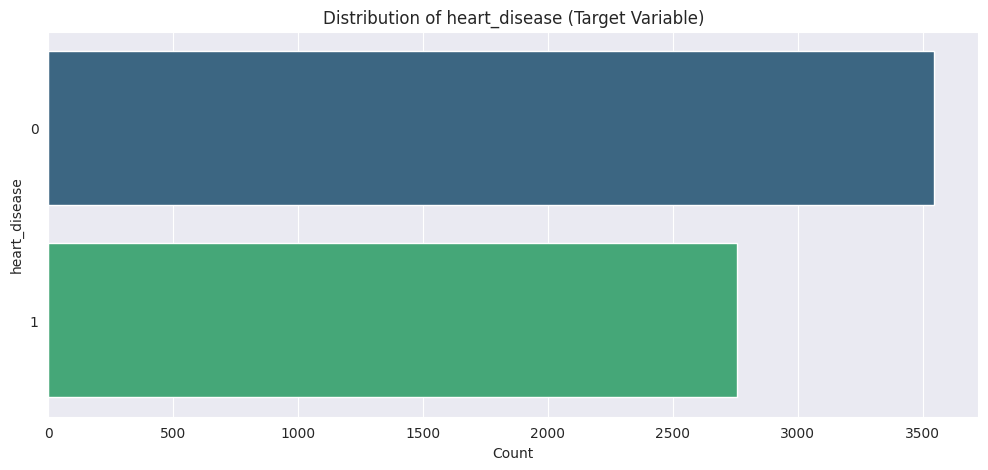

In [ ]:
# Plot target
eda.target_plot()

---
# $$📊 \ Visualize \ Data \ Distribution \ (Univariate \ Analysis)$$

## $Numeric \ Features$

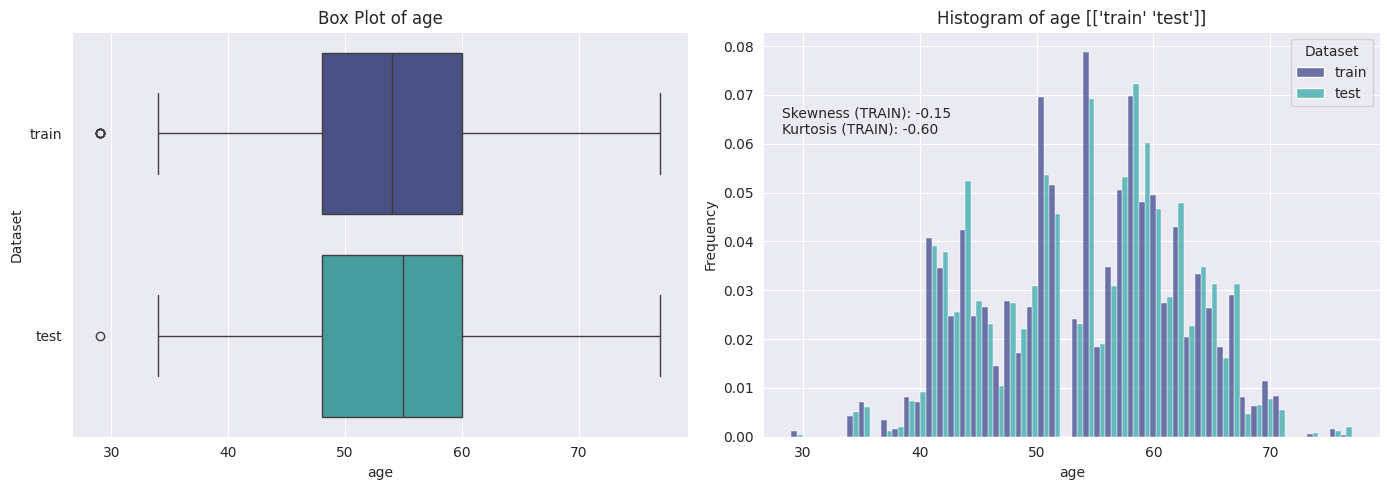

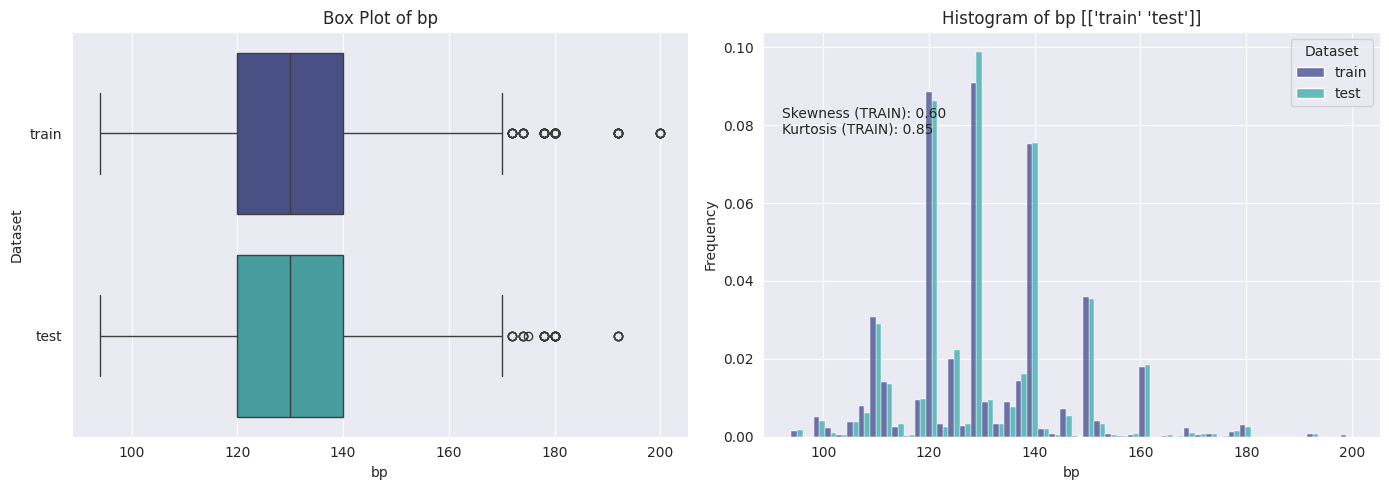

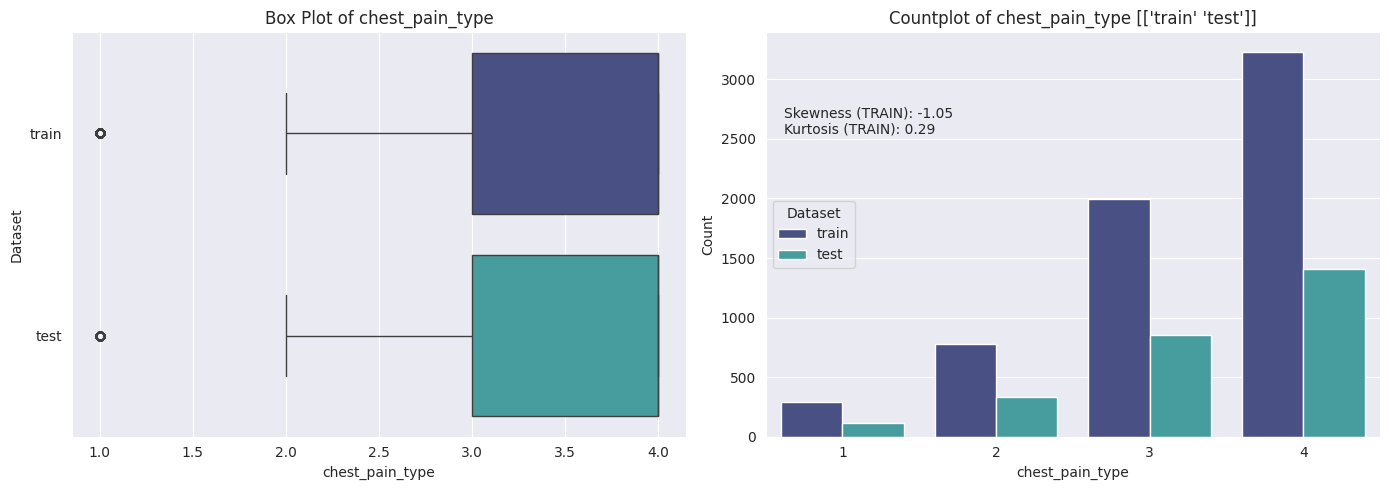

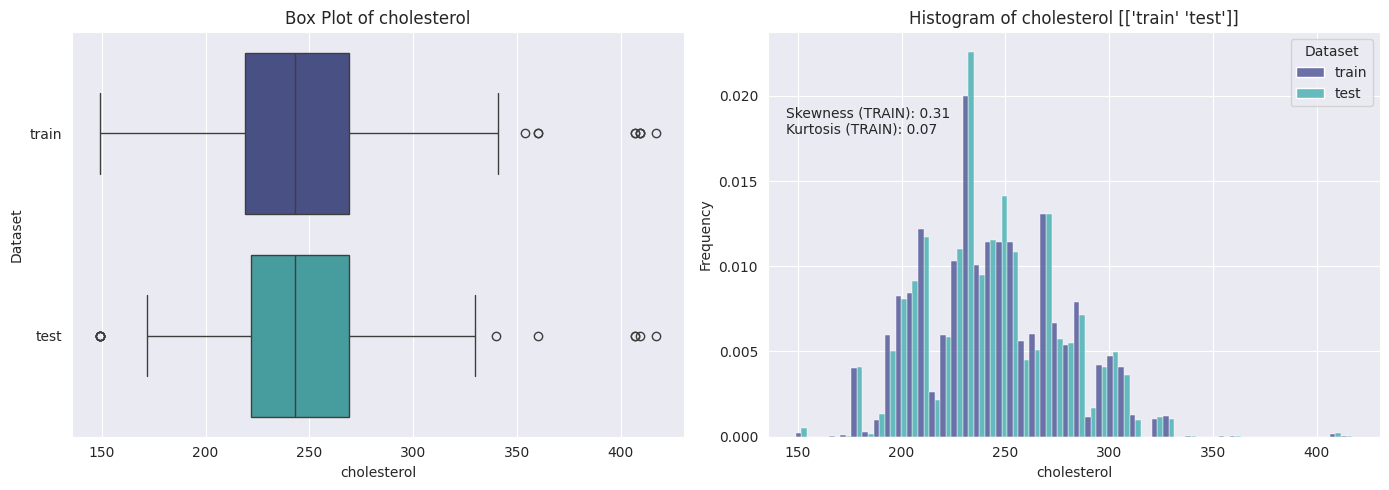

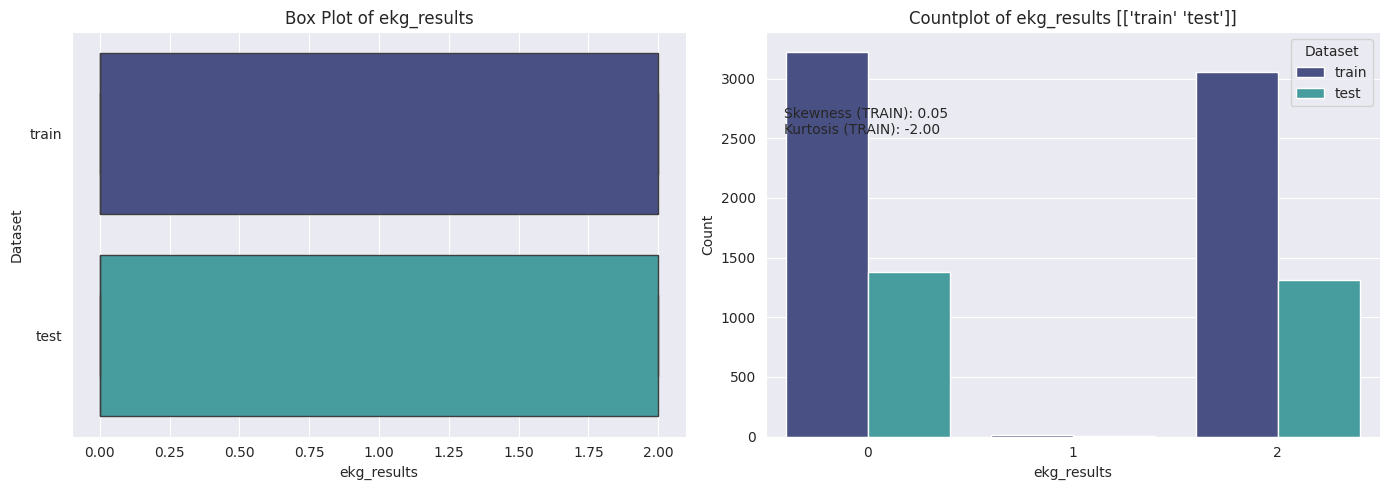

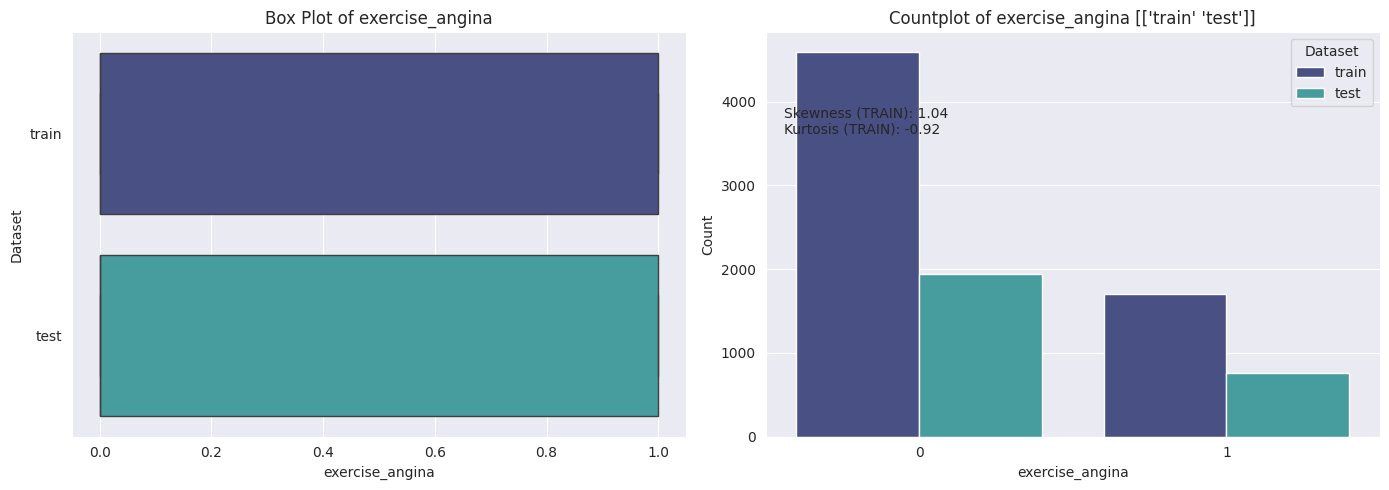

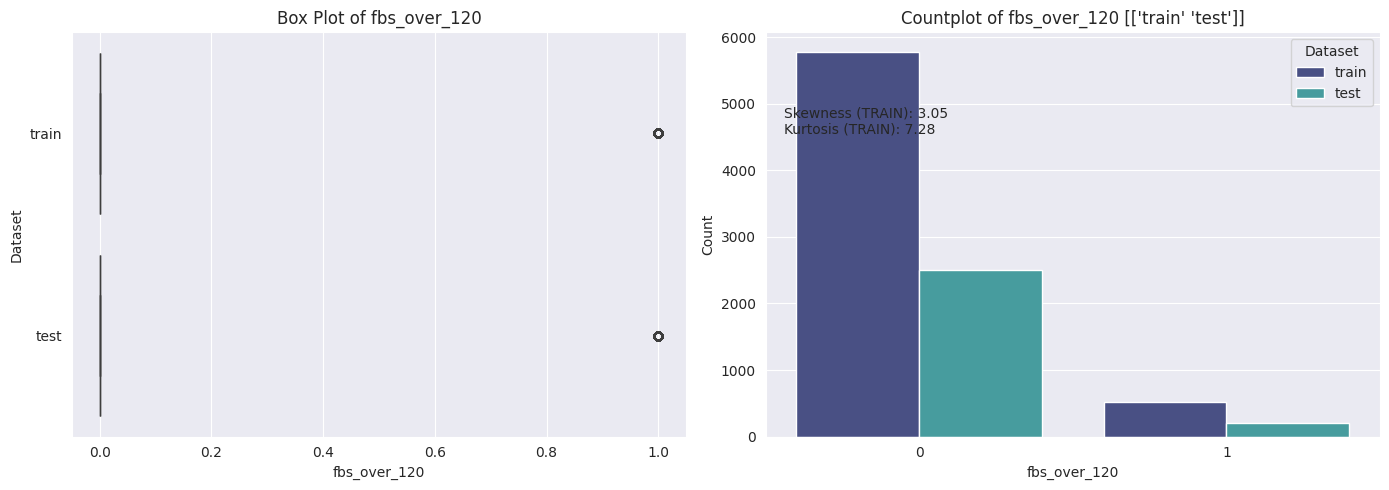

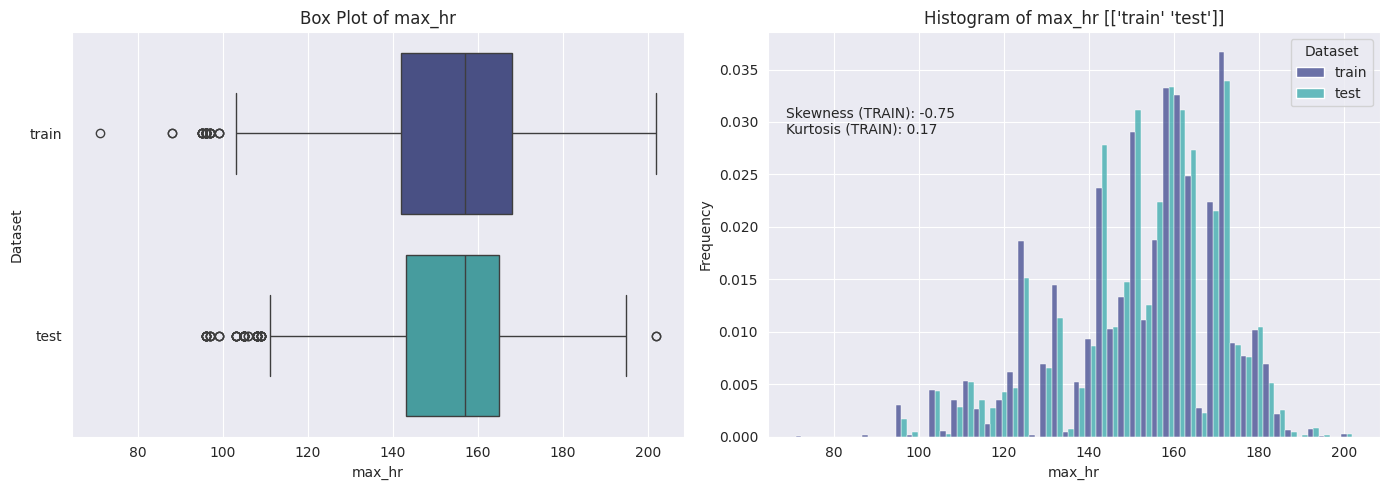

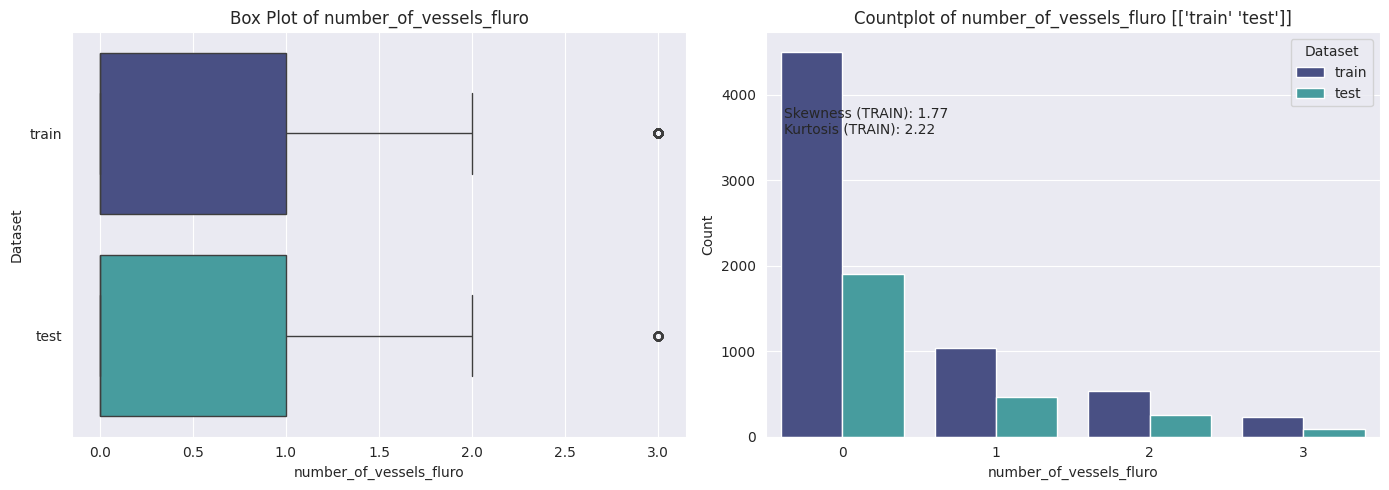

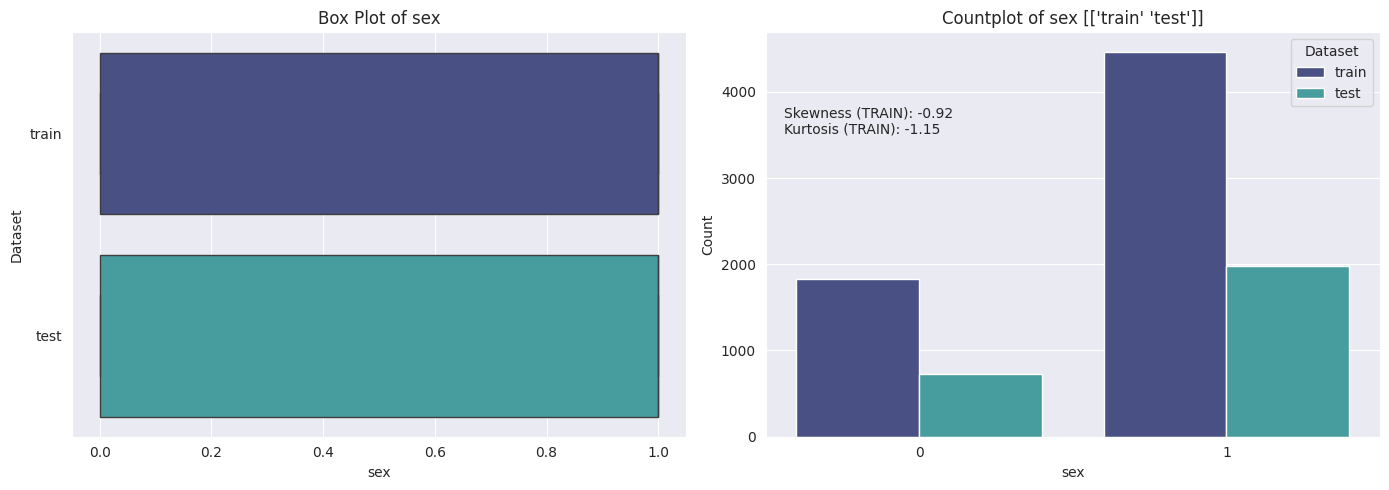

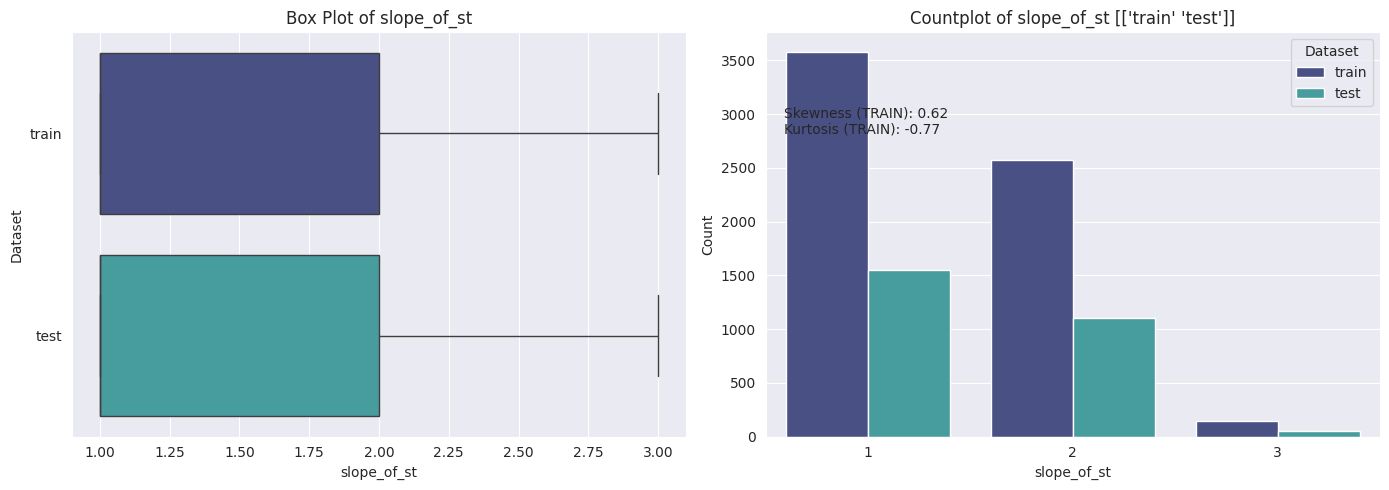

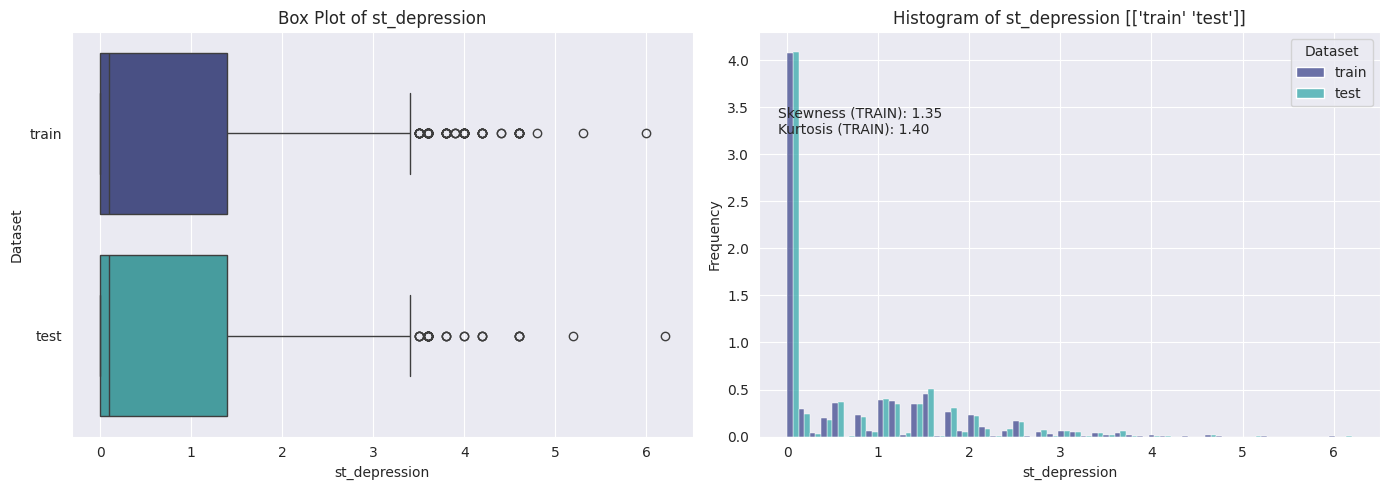

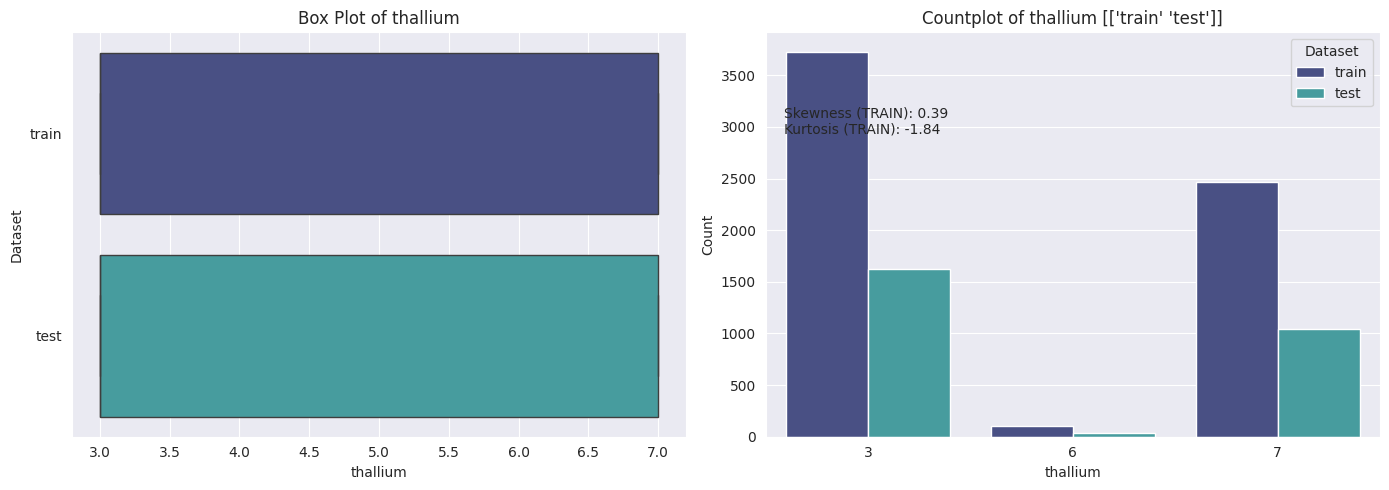

In [ ]:
# Perform univariate analysis for each numerical variable
eda.numeric_univariate_plots()

## $Categorical \ features$

In [ ]:
eda.categorical_plot()

No categorical features to plot.


---
# $$ 📊 Correlations \ - \ Bivariate \ Analysis$$

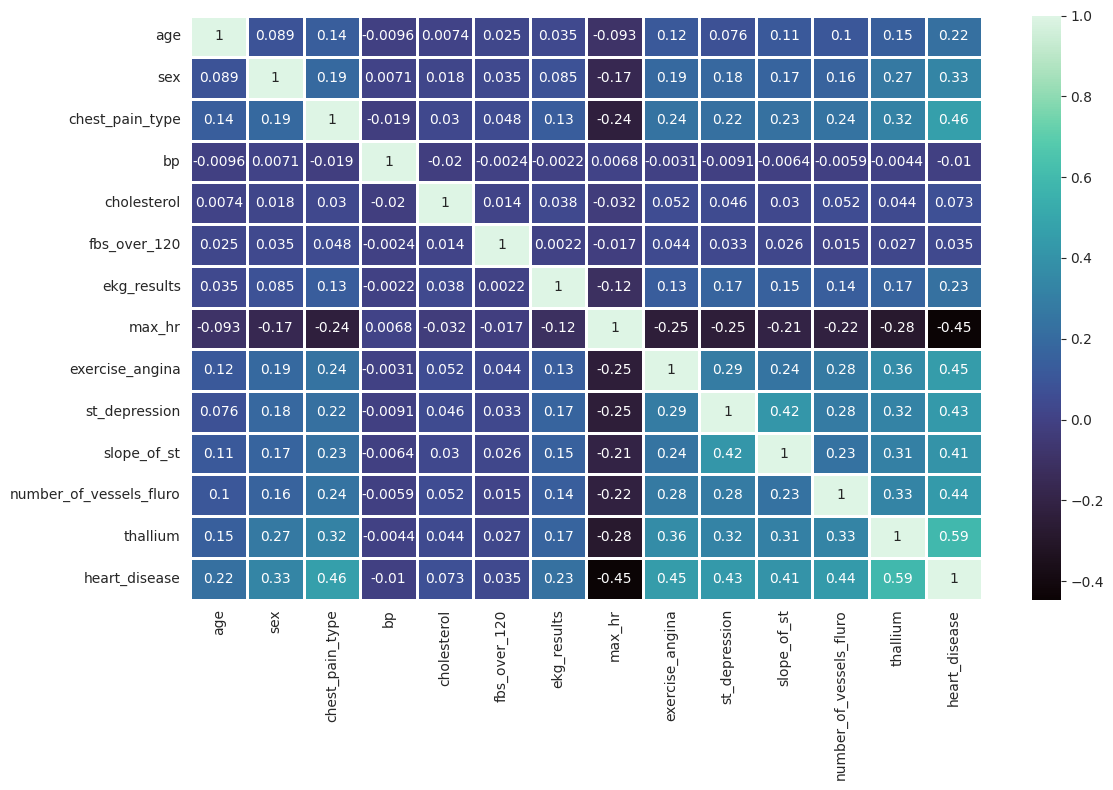

In [ ]:
# Create a heatmap to visualize the correlation matrix of the TRAIN_DF DataFrame
eda.correlation_plot()

---
# $$⚔️ \ Adversarial \ validation$$

In [ ]:
if config.data.add_extra_data:
    from sklearn.model_selection import cross_validate
    from sklearn.preprocessing import OrdinalEncoder

    # Make copies for AV
    av_train = datasets["train"].copy()
    av_extra = datasets["extra"].copy()

    # Drop the target variable
    av_train.drop(config.data.target, axis=1, inplace=True)
    av_extra.drop(config.data.target, axis=1, inplace=True)

    # Add the dataset labels
    av_train["av_label"] = 1
    av_extra["av_label"] = 0

    # Concatenate
    adversarial_df = pd.concat([
      av_train,
      av_extra
    ], axis=0, ignore_index=True)

    # Shuffle
    adversarial_df = adversarial_df.sample(frac=1, random_state=config.env.seed)

    # Define estimator and cv
    estimator = LGBMClassifier(objective="binary",verbose=0)

    # Define X and y
    X = adversarial_df.copy()
    y = X.pop("av_label")

    # Encode categorical
    enc = OrdinalEncoder()
    cat_cols = X.copy().select_dtypes("object").columns
    X[cat_cols] = pd.DataFrame(enc.fit_transform(X[cat_cols].copy()), columns=cat_cols)

    # Turn booleans into integers
    bool_cols = X.copy().select_dtypes("bool").columns
    X[bool_cols] = X[bool_cols].astype(int)

    # Cross validate
    cv_data = pd.DataFrame(
      cross_validate(
      estimator,
          X=X,
          y=y,
          cv=5,    # documentation: "if the estimator is a classifier and y is either binary or multiclass, StratifiedKFold is used"
          scoring="roc_auc",
          fit_params = {
              "eval_metric":"auc"
          }
      )
    )

    # Display results
    display(cv_data)
    AV_RESULTS = np.mean(cv_data['test_score'])
    print(f"Mean cv: {AV_RESULTS}")

In [ ]:
if config.data.add_extra_data:
  # https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/
  plt.figure(figsize=(8, 6))

  # Initialize skfold
  skf = StratifiedKFold(n_splits=config.data.folds, random_state=config.env.seed, shuffle=True)

  # Initialize empty lists to store results
  fprs = []
  tprs = []
  aucs = []

  for i, (train_index, test_index) in enumerate(skf.split(X, y)):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      estimator.fit(X_train, y_train)
      y_hat = estimator.predict_proba(X_test)[:, 1]

      fpr, tpr, _ = roc_curve(y_test, y_hat)
      roc_auc = auc(fpr, tpr)

      tprs.append(tpr)
      fprs.append(fpr)
      aucs.append(roc_auc)

      plt.plot(fpr, tpr, lw=1, alpha=0.7, label=f'Fold {i+1} ROC curve (AUC = {roc_auc:.2f})')

  # Plot chance line
  plt.plot([0, 1], [0, 1], linestyle='--', color='r', lw=2, label='Chance')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC AUC Curves from Adversarial Validation')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

In [ ]:
if config.data.add_extra_data:
    # What helps telling the difference between competition dataset vs additional dataset
    fig, ax =plt.subplots(figsize=(12,6))
    lgb.plot_importance(estimator,ax=ax)
    plt.show()

In [ ]:
if config.data.add_extra_data:
    # Check distribution shift of primary suspects
    adversarial_features = []
    eda.numeric_univariate_plots(
        {k: datasets[k][adversarial_features] for k in ['train', 'extra']},
        CFG["TARGET"]
    )

In [ ]:
if config.data.add_extra_data:
    if AV_RESULTS > config.model.adversarial_threshold:
        print(f"Adversarial threshold exceeded: {config.model.adversarial_threshold} < {AV_RESULTS:.2f}")
    else:
        print(f"Adversarial threshold NOT exceeded: {config.model.adversarial_threshold} > {AV_RESULTS:.2f}")

In [ ]:
# Add extra data to train dataset
if config.data.add_extra_data:
    if AV_RESULTS < config.model.adversarial_threshold:
        print(f"Adversarial threshold NOT exceeded: {config.model.adversarial_threshold} > {AV_RESULTS:.2f}. Concatenating...")
        datasets["train"] = pd.concat([
            datasets["train"],
            datasets["extra"],
        ], axis=0, ignore_index=True)
    else:
        print(f"Adversarial threshold exceeded: {config.model.adversarial_threshold} < {AV_RESULTS:.2f}")

---
# $$🛠 \ Feature \ Engineer$$

In [ ]:
# Define X and y
X = datasets["train"].copy()
X_test = datasets["test"].copy()
y = X.pop(config.data.target)

# == [WIP] ==
# def ???

def interact(df, numeric_features):
    temp_df = df.copy()

    # Set rest aside for the moment
    other_cols = [col for col in temp_df.columns if col not in numeric_features]

    # Interactions
    interactions = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_interactions = interactions.fit_transform(temp_df[numeric_features])

    ## Get feature names for the new interaction terms
    interaction_names = interactions.get_feature_names_out(numeric_features)
    interaction_names = [name.replace(" ", "_X_") for name in interaction_names]

    # Create a DataFrame for the new interaction features
    # Ensure the index of this new DataFrame matches the original DataFrame's index
    interactions_df = pd.DataFrame(X_interactions, columns=interaction_names, index=temp_df.index)

    return pd.concat([temp_df[other_cols], interactions_df],axis=1)

def preprocessing(df, numeric_features):
  temp_df = df.copy()

  # Feature engineering [WIP]
  # temp_df = ???

  # Then, generate interactions using all current numerical features, including the new 'subgrade'
  temp_df = interact(temp_df, numeric_features)

  return temp_df

# Preprocess data
if config.data.add_features:
    X       = preprocessing(X, numeric_features=NUMERIC_FEATURES)
    X_test  = preprocessing(X_test, numeric_features=NUMERIC_FEATURES)

=== Running Consensus Importance Pass ===
Fitting XGB...
Fitting LGBM...
[LightGBM] [Info] Number of positive: 2755, number of negative: 3545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5720
[LightGBM] [Info] Number of data points in the train set: 6300, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.437302 -> initscore=-0.252121
[LightGBM] [Info] Start training from score -0.252121
Fitting CAT...


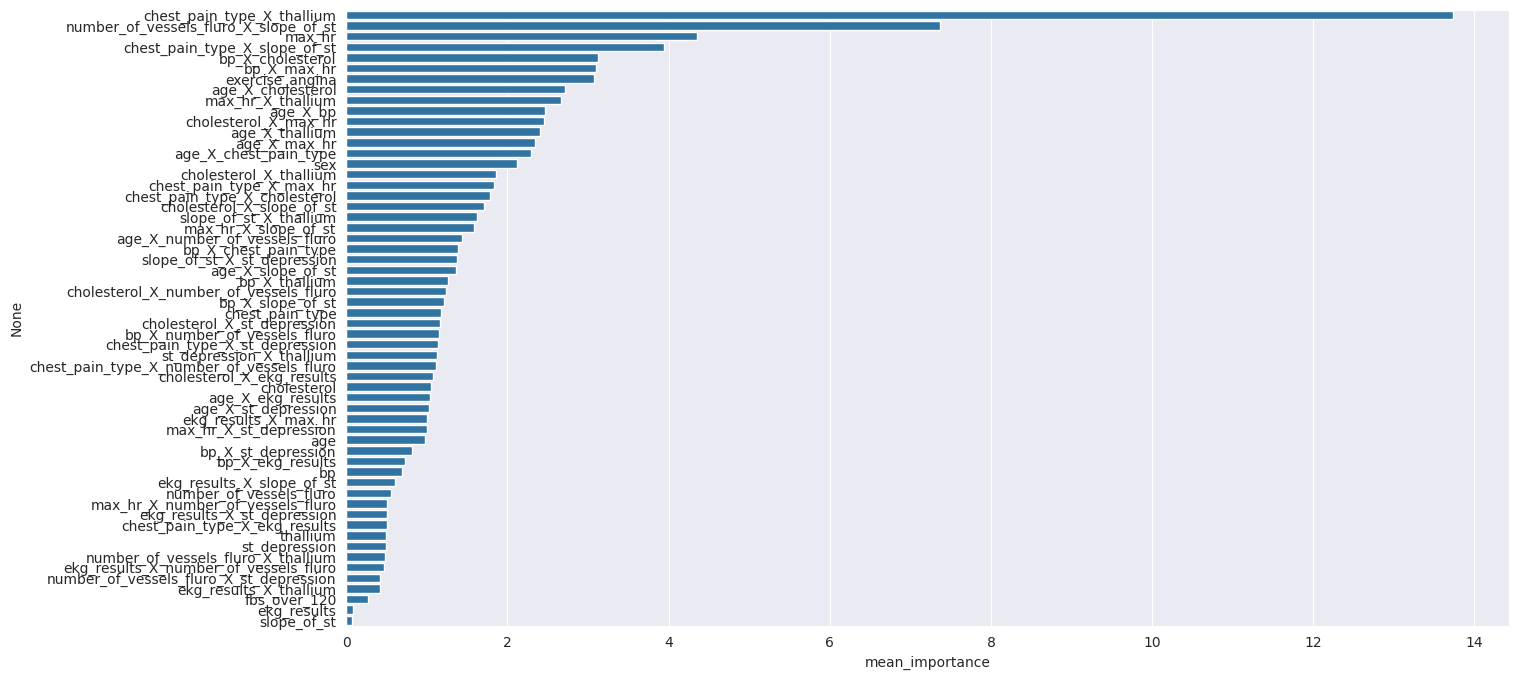

In [ ]:
if config.data.feature_selection:

    # Prepare Categorical Indices for CatBoost/LGBM
    CAT_COLS = X.select_dtypes(["category", "object"]).columns.tolist()
    cat_features_indices = [X.columns.get_loc(col) for col in CAT_COLS]

    # "Light" versions of models for speed
    # We use lower complexity here just to identify feature signal
    importance_models = {
        "XGB": XGBClassifier(n_estimators=500, max_depth=4, device=config.env.device, random_state=config.env.seed),
        "LGBM": LGBMClassifier(n_estimators=500, num_leaves=30, device=config.env.device, random_state=config.env.seed),
        "CAT": CatBoostClassifier(iterations=500, depth=6, verbose=0, task_type=config.env.device.upper(), random_state=config.env.seed)
    }

    importance_results = pd.DataFrame(index=X.columns)

    print("=== Running Consensus Importance Pass ===")
    for name, model in importance_models.items():
        print(f"Fitting {name}...")

        if name == "CAT":
            model.fit(X, y, cat_features=CAT_COLS)
            importance_results[name] = model.get_feature_importance()
        elif name == "LGBM":
            model.fit(X, y, categorical_feature=CAT_COLS)
            importance_results[name] = model.feature_importances_
        else: # XGB
            model.fit(X, y)
            importance_results[name] = model.feature_importances_

        # Normalize scores to 0-100 to make them comparable
        importance_results[name] = (importance_results[name] / importance_results[name].sum()) * 100

    # Calculate Global Score and Perform Selection
    importance_results['mean_importance'] = importance_results.mean(axis=1)
    importance_results = importance_results.sort_values('mean_importance', ascending=False)

    # Plot average feature importance
    plt.figure(figsize=(15,8))
    sns.barplot(
        data=importance_results,
        y=importance_results.index,
        x='mean_importance'
    )

In [ ]:
if config.data.feature_selection:
    # Selection: Keep features that contribute at least 2% or are in top 30
    THRESHOLD = 2
    SELECTED_FEATURES = importance_results[importance_results['mean_importance'] > THRESHOLD].index.tolist()
    print(f"\nSelection Complete: {len(SELECTED_FEATURES)} features retained.")
    print(f"Dropped: {len(X.columns) - len(SELECTED_FEATURES)} features.")

    X = X[SELECTED_FEATURES]
    X_test = X_test[SELECTED_FEATURES]


Selection Complete: 15 features retained.
Dropped: 43 features.


---
# $$Hyperparameter \ Optimization$$

In [ ]:
def objective(trial, X, y, model_type):
    if model_type == "xgboost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-9, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-9, 10.0, log=True),
            'enable_categorical': True,
            # 'use_label_encoder': False,
            'eval_metric': 'rmse',
            'early_stopping_rounds' : 100,
            'device': CFG["DEVICE"],
            'random_state': config.env.seed,
        }
        model = XGBRegressor(**params)

    elif model_type == "lightgbm":
        params = {
            'n_estimators': trial.suggest_int("n_estimators", 200, 1500),
            'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int("num_leaves", 15, 150),
            'min_child_samples': trial.suggest_int("min_child_samples", 10, 100),
            'subsample': trial.suggest_float("subsample", 0.5, 1.0),
            'colsample_bytree': trial.suggest_float("colsample_bytree", 0.5, 1.0),
            'reg_alpha': trial.suggest_float("reg_alpha", 0.0, 10.0),
            'reg_lambda': trial.suggest_float("reg_lambda", 0.0, 10.0),
            'verbose':-1,
            'device': CFG["DEVICE"],
            'random_state': config.env.seed
        }
        model = LGBMRegressor(**params)

    elif model_type == "catboost":
        params = {
            'iterations': trial.suggest_int("iterations", 200, 1000),
            'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            'depth': trial.suggest_int("depth", 4, 10),
            'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            'random_state': config.env.seed,
            'verbose': 0,
            'task_type': CFG["DEVICE"].upper(),
            'allow_writing_files': False
        }
        model = CatBoostRegressor(**params)

    else:
        print(f"Error: Unsupported model_type received: {model_type}")
        raise ValueError("Unsupported model_type")

    # Initialize skf
    FOLDS = 3
    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=config.env.seed)

    # # Define TE cols
    # TE_cols = [""] # TE can be applied also with low cardinality numeric features
    # X[TE_cols] = X[TE_cols].astype("category") # not necessary, but good practice

    scores = []

    print(f"\n{'='*20} Fitting {model_type} {'='*20}")
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, pd.qcut(y, q = 10).cat.codes)):
        print(f"\n{'#'*10} Fold {fold+1}/{FOLDS} {'#'*10}")

        # Define splits
        x_train, x_valid, _ = iqr_outlier_capping(X.iloc[train_idx], X.iloc[valid_idx], None, columns = X.select_dtypes('number').columns.difference([CFG["TARGET"]]))
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        if CFG["USE_TE"]:
            # Initialize target encoder
            target_enc = TargetEncoder(target_type='continuous', smooth='auto', cv=4, shuffle=True, random_state=config.env.seed)

            # Encode
            x_train[TE_cols] = target_enc.fit_transform(x_train[TE_cols], y_train)
            x_valid[TE_cols] = target_enc.transform(x_valid[TE_cols])

        start = time.time()

        if model_type == "xgboost":
            model.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)], # Use validation set for early stopping
                    verbose=200,
                    # early_stopping_rounds=100
                    )

        if model_type == "lightgbm":
            model.fit(x_train, y_train,
                      categorical_feature=CAT_COLS,
                      eval_set=(x_valid, y_valid),
                      callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=200)],
                            )
        if model_type == "catboost":
            model.fit(x_train, y_train,
                      eval_set=(x_valid, y_valid), # Use validation set for early stopping
                      cat_features=CAT_COLS, # Pass categorical features to CatBoost
                      verbose=200,
                      early_stopping_rounds=100
                        )
        # else:
        #   raise ValueError("Unsupported model_type")

        preds  = model.predict(x_valid)
        score  = mean_squared_error(y_valid, preds, squared=False)
        scores.append(score)
        end = time.time()

        print(f"RMSE: {score:.4f} | Time: {end - start:.2f}s")

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Checkpoint description
    print(f"Mean k-FOLDS score: {np.mean(scores)} +- {np.std(scores)}")

    return np.mean(scores)

In [ ]:
if config.model.hp_search:
    # Optimize with Optuna
    study_results = dict()
    for model_type in ["xgboost", "lightgbm", "catboost"]:
      study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=config.env.seed))
      study.optimize(
          lambda trial: objective(
              trial,
              X.sample(frac=.05, random_state=config.env.seed),
              y.sample(frac=.05, random_state=config.env.seed),
              model_type=model_type
          ),
          n_trials=config.model.optuna_trials, timeout=7200)

      # Nest params, value and trial within each model's dictionary
      model_results = dict()
      model_results["Model"] = model_type
      model_results["Best params:"] = study.best_params
      model_results["Best value:"] = study.best_value
      model_results["Best trial:"] = study.best_trial

      # Append to study results
      study_results[model_type] = model_results

    # Display the results
    study_df = pd.DataFrame.from_records(study_results)
    for model_type in ["xgboost", "lightgbm", "catboost"]:
      display(pd.DataFrame.from_records(study_results[model_type]))

In [ ]:
if config.model.optimized_params:
  XGB_PARAMS  = {
      'n_estimators': 1009,
      'learning_rate': 0.011943333544787549,
      'max_depth': 8,
      'subsample': 0.9143965635679931,
      'colsample_bytree': 0.7670542318585548,
      'reg_alpha': 3.0303575179672426e-05,
      'reg_lambda': 1.0218338193771584e-06,
      "device": config.env.device,
      "random_state":config.env.seed,
      "early_stopping_rounds":100,
  }

  LGBM_PARAMS = {
      'n_estimators': 1384,
      'learning_rate': 0.030159004697110012,
      'num_leaves': 81,
      'min_child_samples': 56,
      'subsample': 0.7668992634198386,
      'colsample_bytree': 0.7539783365264743,
      'reg_alpha': 2.5249266600932376,
      'reg_lambda': 1.2022289464728586,
      "device": config.env.device,
      "random_state":config.env.seed
  }
  CAT_PARAMS  = {
      'iterations': 909,
      'learning_rate': 0.1056470526055604,
      'depth': 6,
      'l2_leaf_reg': 9.897294454000193,
      "task_type": config.env.device.upper(),
      "random_state":config.env.seed
  }

else:
    XGB_DEFAULT = {
        'objective': 'binary:logistic',
        'n_estimators': 1_000,
        'learning_rate': 0.02,
        'max_depth': 4,
        'subsample': 0.8,
        'colsample_bytree': 0.6,
        'reg_alpha': 1.5,
        'reg_lambda': 3.0,
        'tree_method': "hist",
        'enable_categorical': True,
        'eval_metric': 'auc',
        'device': config.env.device,
        'random_state': config.env.seed,
        'early_stopping_rounds': 100,
    }

    LGBM_DEFAULT = {
        'objective': 'binary',
        'n_estimators': 1_000,
        'learning_rate': 0.02,
        'num_leaves': 40,
        'min_child_samples': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.6,
        'reg_alpha': 1.0,
        'reg_lambda': 2.0,
        'metric': 'auc',
        'device': config.env.device,
        'random_state': config.env.seed,
        'verbose': -1
    }

    CAT_DEFAULT = {
        'iterations': 1_000,
        'learning_rate': 0.02,
        'depth': 6,
        'l2_leaf_reg': 5.0,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': config.env.device.upper(),
        'random_state': config.env.seed,
        'early_stopping_rounds': 100,
        'verbose': 0
    }

# $$Training$$

In [ ]:
# Define estimators group with best hyperparams (if available)
estimators = [
    ('xgboost',  XGBClassifier(**XGB_PARAMS)      if config.model.optimized_params  else XGBClassifier(**XGB_DEFAULT)),
    ('lightgbm', LGBMClassifier(**LGBM_PARAMS)    if config.model.optimized_params  else LGBMClassifier(**LGBM_DEFAULT)),
    ('catboost', CatBoostClassifier(**CAT_PARAMS) if config.model.optimized_params  else CatBoostClassifier(**CAT_DEFAULT)),
    ]

# Initialize dictionaries to keep predictions from each model
OOF_PREDS   = dict()
TEST_PREDS  = dict()
FOLD_SCORES = dict()

# Initialize skf (outside of loop so each model gets the same splits)
skf = StratifiedKFold(n_splits=config.data.folds, shuffle=True, random_state=config.env.seed)

# Start model loop
for model_type, model in estimators:

    # Define empty oof variables to fill
    oof_preds   = np.zeros(shape = (len(X)))
    test_preds  = np.zeros(shape = (len(X_test),))
    fold_scores = []

    scores = []

    # Define TE cols
    # TE_cols = []
    # X[TE_cols] = X[TE_cols].astype("category")

    print(f"\n{'='*20} Fitting {model_type} {'='*20}")
    # for fold, (train_idx, valid_idx) in enumerate(skf.split(X, pd.qcut(y, q=10).cat.codes)):
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n{'#'*10} Fold {fold+1}/{config.data.folds} {'#'*10}")

        # Define splits
        x_train, x_valid, _ = iqr_outlier_capping(X.iloc[train_idx], X.iloc[valid_idx], None, columns = X.select_dtypes(np.number).columns.difference([config.data.target]))
        y_train, y_valid    = y.iloc[train_idx], y.iloc[valid_idx]
        x_test_loop         = X_test.copy()

        if config.data.use_te:
            # Initialize target encoder
            target_enc = TargetEncoder(target_type='auto', smooth='auto', cv=4, shuffle=True, random_state=config.env.seed)

            # Encode
            x_train[TE_cols]     = target_enc.fit_transform(x_train[TE_cols], y_train)
            x_valid[TE_cols]     = target_enc.transform(x_valid[TE_cols])
            x_test_loop[TE_cols] = target_enc.transform(x_test_loop[TE_cols])

            # REMOVE TE_cols from the categorical list for this fold
            CAT_COLS = [c for c in CAT_COLS if c not in TE_cols]

        start = time.time()

        if model_type == "xgboost":
            model.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)], # Use validation set for early stopping
                    verbose=200
                      # early_stopping_rounds moved to arguments
                    )
        if model_type == "lightgbm":
            model.fit(x_train, y_train,
                      categorical_feature=CAT_COLS,
                      eval_set=(x_valid, y_valid),
                      callbacks = [
                          lgb.early_stopping(stopping_rounds=100, verbose=200)],
                     )
        if model_type == "catboost":
            model.fit(x_train, y_train,
                      eval_set=(x_valid, y_valid), # Use validation set for early stopping
                      cat_features=CAT_COLS, # Pass categorical features to CatBoost
                      verbose=200,
                      early_stopping_rounds=100
                     )

        # Get predictions and Predict OOF and test
        oof_preds[valid_idx] = model.predict_proba(x_valid)[:,1]
        test_preds += model.predict_proba(x_test_loop)[:,1]

        preds      = model.predict_proba(x_valid)[:,1]
        fold_score = roc_auc_score(y_valid, preds)
        fold_scores.append(fold_score)
        print(f" Fold {fold+1}: ROC_AUC Score: {fold_score:.5f}")

        end = time.time()
        print(f"Fold {fold+1} finished in {end - start:.2f} seconds")

    mean_valid_score = np.mean(fold_scores); print(f"Mean ROC_AUC: {mean_valid_score:.3f}")
    test_predictions = test_preds / config.data.folds

    # Save OOF and test predictions + fold scores by model
    OOF_PREDS[model_type]   = oof_preds
    TEST_PREDS[model_type]  = test_predictions
    FOLD_SCORES[model_type] = fold_scores


==================== Fitting xgboost ====================

########## Fold 1/5 ##########
[0]	validation_0-auc:0.90948
[200]	validation_0-auc:0.93974
[400]	validation_0-auc:0.94099
[443]	validation_0-auc:0.94106
 Fold 1: ROC_AUC Score: 0.94115
Fold 1 finished in 0.94 seconds

########## Fold 2/5 ##########
[0]	validation_0-auc:0.88638
[200]	validation_0-auc:0.93881
[400]	validation_0-auc:0.94010
[572]	validation_0-auc:0.93986
 Fold 2: ROC_AUC Score: 0.94029
Fold 2 finished in 1.57 seconds

########## Fold 3/5 ##########
[0]	validation_0-auc:0.91254
[200]	validation_0-auc:0.94674
[400]	validation_0-auc:0.94680
[460]	validation_0-auc:0.94661
 Fold 3: ROC_AUC Score: 0.94703
Fold 3 finished in 0.74 seconds

########## Fold 4/5 ##########
[0]	validation_0-auc:0.92367
[200]	validation_0-auc:0.95490
[291]	validation_0-auc:0.95483
 Fold 4: ROC_AUC Score: 0.95499
Fold 4 finished in 0.50 seconds

########## Fold 5/5 ##########
[0]	validation_0-auc:0.91619
[200]	validation_0-auc:0.95299
[357]	va

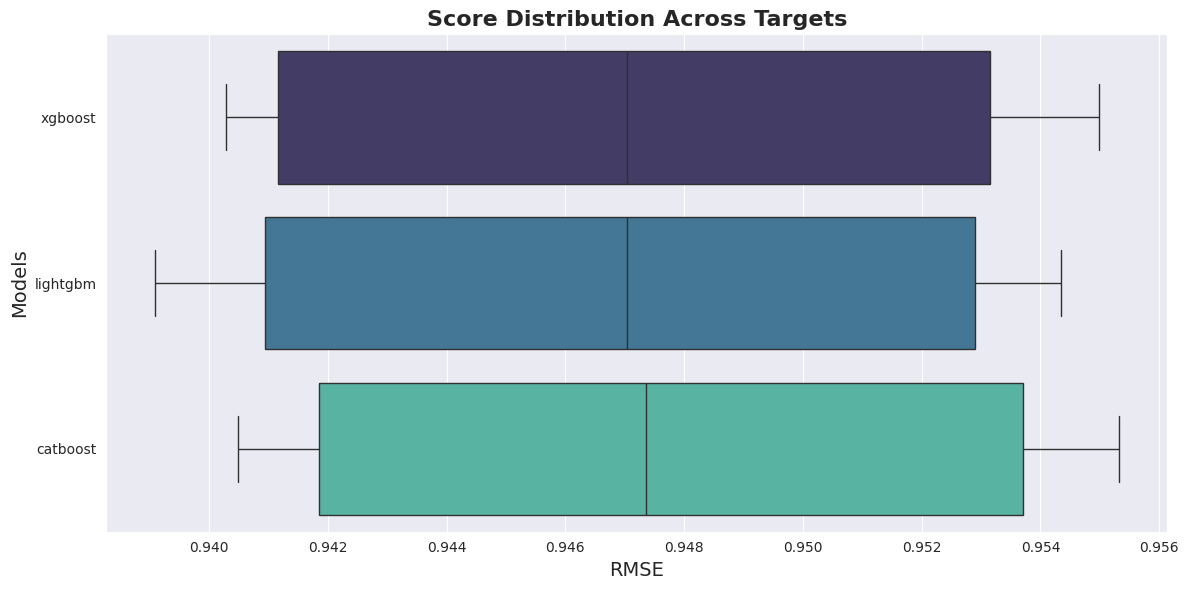

In [ ]:
scores_df = pd.DataFrame(FOLD_SCORES)

# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=scores_df, palette="mako", orient='h')

# Add titles and labels
plt.title('Score Distribution Across Targets', fontsize=16, weight='bold')
plt.xlabel('RMSE', fontsize=14)
plt.ylabel('Models', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def objective(trial):

    # Sample model weights and normalize
    w1 = trial.suggest_float("w1", 0, 1)
    w2 = trial.suggest_float("w2", 0, 1)
    w3 = 1 - (w1 + w2) # Constraint: weights must sum to 1

    # Skip invalid combinations
    if w3 < 0 or w3 > 1:
        raise optuna.exceptions.TrialPruned()

    # Weighted ensemble of out-of-fold probabilities
    ensemble_preds = (
        w1 * OOF_PREDS["xgboost"]  +
        w2 * OOF_PREDS["lightgbm"] +
        w3 * OOF_PREDS["catboost"]
    )

    score = roc_auc_score(y, ensemble_preds)
    return score

In [ ]:
if config.model.search_weights:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=config.env.seed))
    study.optimize(objective, n_trials = config.model.optuna_trials*10, timeout=3600)

[I 2026-02-22 16:37:51,748] A new study created in memory with name: no-name-6b4388b1-47b6-4232-878a-ad95e71b5b68
[I 2026-02-22 16:37:51,751] Trial 0 pruned. 
[I 2026-02-22 16:37:51,752] Trial 1 pruned. 
[I 2026-02-22 16:37:51,761] Trial 2 finished with value: 0.9469005961721091 and parameters: {'w1': 0.15601864044243652, 'w2': 0.15599452033620265}. Best is trial 2 with value: 0.9469005961721091.
[I 2026-02-22 16:37:51,769] Trial 3 finished with value: 0.9459948446087253 and parameters: {'w1': 0.05808361216819946, 'w2': 0.8661761457749352}. Best is trial 2 with value: 0.9469005961721091.
[I 2026-02-22 16:37:51,770] Trial 4 pruned. 
[I 2026-02-22 16:37:51,777] Trial 5 finished with value: 0.9457780826756839 and parameters: {'w1': 0.020584494295802447, 'w2': 0.9699098521619943}. Best is trial 2 with value: 0.9469005961721091.
[I 2026-02-22 16:37:51,778] Trial 6 pruned. 
[I 2026-02-22 16:37:51,785] Trial 7 finished with value: 0.9468877972861244 and parameters: {'w1': 0.18182496720710062,

In [ ]:
# Print best params (weights)
print(study.best_params)

{'w1': 0.14524939282205554, 'w2': 0.1525506259194374}


# $$✅ \ Submission$$

In [ ]:
# Define best weights and threshold
w1 = study.best_params["w1"]
w2 = study.best_params["w2"]
w3 = 1 - (w2+w1)

# Weighted ensemble of model predictions with weights
ensemble_predictions = (
    w1 * TEST_PREDS["xgboost"]  +
    w2 * TEST_PREDS["lightgbm"] +
    w3 * TEST_PREDS["catboost"]
)

# Submission ids
submission_ids = pd.read_csv(f'{config.data.data_path}/sample_submission.csv').id.to_list()

# Prepare submission df
submission_df = pd.DataFrame({
    "id": submission_ids,
    "exam_score" : ensemble_predictions
})

# Display the first rows (sanity check)
display(submission_df.head())

# Save to CSV
submission_df.to_csv('submission.csv', index=False)